# NEST-compatible modeling with ``brainpy.state``

[![Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/chaobrain/brainx/blob/main/docs/tutorials/brainpy.state_NEST_compatible.ipynb)
[![Open in Kaggle](https://kaggle.com/static/images/open-in-kaggle.svg)](https://kaggle.com/kernels/welcome?src=https://github.com/chaobrain/brainx/blob/main/docs/tutorials/brainpy.state_NEST_compatible.ipynb)

This tutorial follows the NEST-style workflow exposed by `brainpy.state`:

1. **Create** model nodes and devices;
2. **Connect** populations, projections, and recorders;
3. **Simulate** the network for a duration;
4. **Record** traces and spike events from the result object.

After the one-neuron path, the tutorial expands the same ideas to `NodeView` algebra, connection rules, a small excitatory/inhibitory network, and practical cautions for porting NEST scripts into the BrainX ecosystem.


## Setup

Enable JAX x64 before importing `brainpy.state`, then give each `Simulator` an explicit unit-aware time step. The examples below use milliseconds, picoamperes, and millivolts from `brainunit`.


In [1]:
import jax

import numpy as np
import matplotlib.pyplot as plt

import brainunit as u
import brainpy.state as bp

## 1. Create: model nodes

`Simulator.create()` is the `brainpy.state` counterpart of NEST's `Create`. It returns a `NodeView`, which is a handle to the created population or device.

The example below creates one `iaf_psc_alpha` neuron. Parameters use NEST-compatible names such as `I_e`, `V_th`, `V_reset`, and `E_L`, while values remain explicit `brainunit` quantities.


In [2]:
sim = bp.Simulator(dt=0.1 * u.ms)

neuron = sim.create(
    bp.iaf_psc_alpha,
    params={
        "I_e": 376.0 * u.pA,
        "V_th": -55.0 * u.mV,
        "V_reset": -70.0 * u.mV,
        "E_L": -70.0 * u.mV,
    },
)

print(neuron)
print(f"number of nodes = {len(neuron)}")

number of nodes = 1


## 2. Connect: recording devices

Recording devices follow NEST's connection direction:

- a `voltmeter` observes a neuron, so connect `voltmeter -> neuron`;
- a `spike_recorder` receives spike events, so connect `neuron -> spike_recorder`.

The same `Simulator.connect()` method registers either a projection or a recorder tap depending on the source and target types.


In [3]:
vm = sim.create(bp.voltmeter, interval=0.1 * u.ms)
sr = sim.create(bp.spike_recorder)

sim.connect(vm, neuron)      # voltmeter observes the neuron
sim.connect(neuron, sr)      # spike_recorder receives emitted spikes

print("recorders are connected")

recorders are connected


## 3. Simulate: run the model

`Simulator.simulate()` is the explicit runner. It returns a `SimulationResult` object with helper methods for recorded variables:

- `trace(recorder, "V_m")` returns a membrane-potential trace from a voltmeter or multimeter;
- `spikes(recorder)` returns a time-by-node spike matrix;
- `n_events(recorder)` counts recorded spikes;
- `rate(recorder)` reports the mean firing rate in spikes per second.


In [4]:
result = sim.simulate(80.0 * u.ms)

V_m = result.trace(vm, "V_m")
spikes = result.spikes(sr)
times = result.times

print(f"V_m shape     = {V_m.shape}")
print(f"spikes shape  = {spikes.shape}")
print(f"spike count   = {result.n_events(sr)}")
print(f"firing rate   = {result.rate(sr):.2f} Hz")

V_m shape     = (800, 1)
spikes shape  = (800, 1)
spike count   = 1
firing rate   = 12.50 Hz


## 4. Record: visualize traces and events

The result object separates simulation from analysis. Once the run has finished, use recorder handles to extract arrays and plot them with ordinary Python tools. This mirrors the NEST habit of attaching devices first and reading them after `Simulate`.


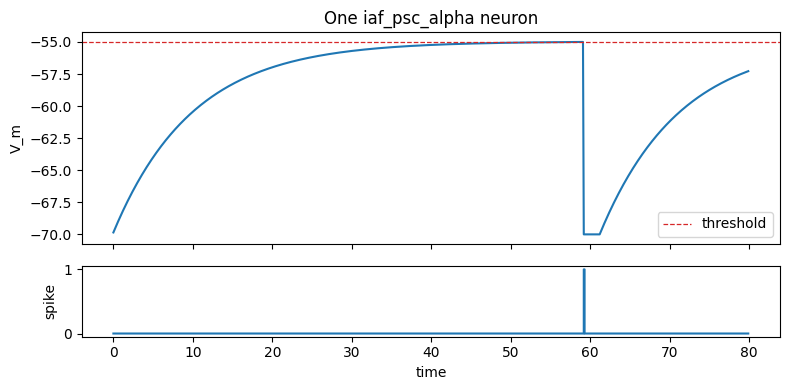

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(8, 4), sharex=True, height_ratios=[3, 1])

axes[0].plot(times, V_m[:, 0])
axes[0].axhline(-55.0 * u.mV, color="tab:red", ls="--", lw=0.9, label="threshold")
axes[0].set_ylabel("V_m")
axes[0].set_title("One iaf_psc_alpha neuron")
axes[0].legend(loc="best")

axes[1].plot(times, spikes[:, 0], drawstyle="steps-post")
axes[1].set_ylabel("spike")
axes[1].set_xlabel("time")

plt.tight_layout()
plt.show()

## 5. NodeView algebra: populations, slices, and groups

A `NodeView` can refer to a full population, a slice of one population, or a concatenation of several views. This gives you a compact way to express NEST-like population algebra while keeping Python objects explicit.

A practical constraint: a single `spike_recorder` records one population segment. If you concatenate two populations, use one recorder per population when you want spike recordings from both groups.


In [6]:
pop_sim = bp.Simulator(dt=0.1 * u.ms)

exc = pop_sim.create(bp.iaf_psc_alpha, 6, params={"I_e": 400.0 * u.pA})
inh = pop_sim.create(bp.iaf_psc_alpha, 3, params={"I_e": 360.0 * u.pA})

first_two_exc = exc[:2]
all_neurons = exc + inh

print(f"exc size           = {len(exc)}")
print(f"inh size           = {len(inh)}")
print(f"first_two_exc size = {len(first_two_exc)}")
print(f"combined size      = {len(all_neurons)}")

exc size           = 6
inh size           = 3
first_two_exc size = 2
combined size      = 9


## 6. Connect: population projections

Connection rules are passed to `sim.connect()` through the `rule` argument. The common pattern is:

```python
sim.connect(pre, post, rule=..., weight=..., delay=..., seed=...)
```

Positive weights drive excitatory current channels, while negative weights drive inhibitory current channels for current-based NEST-compatible neurons. Delays are unit-aware time quantities.

For known dense examples, the default communication path is fine. For larger sparse networks, `comm="sparse"` routes event delivery through sparse communication while preserving the same high-level `connect()` interface.


In [7]:
# E -> I: sparse random excitatory projection.
pop_sim.connect(
    exc,
    inh,
    rule=bp.pairwise_bernoulli(0.5),
    weight=20.0 * u.pA,
    delay=1.0 * u.ms,
    seed=1,
)

# I -> E: sparse random inhibitory projection.
pop_sim.connect(
    inh,
    exc,
    rule=bp.pairwise_bernoulli(0.5),
    weight=-45.0 * u.pA,
    delay=1.0 * u.ms,
    seed=2,
)

print("E/I projections are connected")

E/I projections are connected


### Deterministic connection rules

The same interface also covers deterministic rules. This cell uses a separate simulator only to show the API shape without interfering with the E/I example above.


In [8]:
rule_sim = bp.Simulator(dt=0.1 * u.ms)
pre = rule_sim.create(bp.iaf_psc_alpha, 3, params={"I_e": 380.0 * u.pA})
post = rule_sim.create(bp.iaf_psc_alpha, 3)

one_to_one_proj = rule_sim.connect(
    pre,
    post,
    rule=bp.one_to_one,
    weight=15.0 * u.pA,
    delay=1.0 * u.ms,
)

all_to_all_proj = rule_sim.connect(
    pre,
    post,
    rule=bp.all_to_all,
    weight=5.0 * u.pA,
    delay=1.0 * u.ms,
)

print(type(one_to_one_proj).__name__)
print(type(all_to_all_proj).__name__)

EventProjection
EventProjection


## 7. Record: a small E/I network

Now attach one spike recorder to the excitatory population and one to the inhibitory population. This keeps each recorder tied to a single population segment, which is the supported recording layout for spike recorders.


In [9]:
exc_rec = pop_sim.create(bp.spike_recorder)
inh_rec = pop_sim.create(bp.spike_recorder)

pop_sim.connect(exc, exc_rec)
pop_sim.connect(inh, inh_rec)

net_result = pop_sim.simulate(80.0 * u.ms)

exc_spikes = net_result.spikes(exc_rec)
inh_spikes = net_result.spikes(inh_rec)

print(f"exc_spikes shape = {exc_spikes.shape}")
print(f"inh_spikes shape = {inh_spikes.shape}")
print(f"exc events       = {net_result.n_events(exc_rec)}")
print(f"inh events       = {net_result.n_events(inh_rec)}")
print(f"exc rate         = {net_result.rate(exc_rec):.2f} Hz")
print(f"inh rate         = {net_result.rate(inh_rec):.2f} Hz")

exc_spikes shape = (800, 6)
inh_spikes shape = (800, 3)
exc events       = 12
inh events       = 2
exc rate         = 25.00 Hz
inh rate         = 8.33 Hz


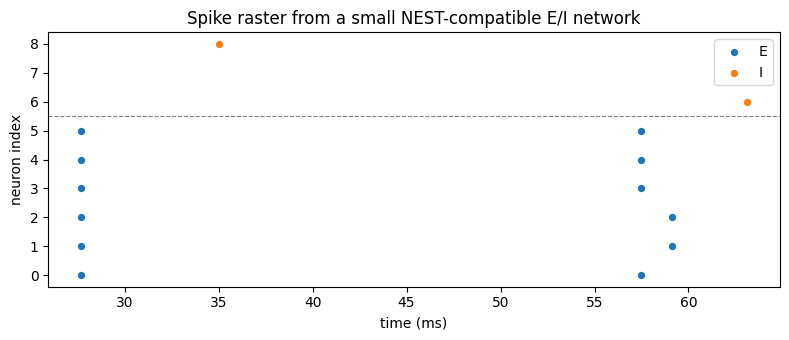

In [10]:
def raster_points(spike_matrix, offset=0):
    t_idx, neuron_idx = np.where(np.asarray(spike_matrix) > 0)
    return t_idx, neuron_idx + offset

exc_t, exc_id = raster_points(exc_spikes, offset=0)
inh_t, inh_id = raster_points(inh_spikes, offset=len(exc))

time_values = np.asarray(net_result.times.to_decimal(u.ms))

plt.figure(figsize=(8, 3.5))
if len(exc_t):
    plt.scatter(time_values[exc_t], exc_id, s=18, label="E", color="tab:blue")
if len(inh_t):
    plt.scatter(time_values[inh_t], inh_id, s=18, label="I", color="tab:orange")

plt.axhline(len(exc) - 0.5, color="0.5", lw=0.8, ls="--")
plt.xlabel("time (ms)")
plt.ylabel("neuron index")
plt.title("Spike raster from a small NEST-compatible E/I network")
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

## 8. Translate NEST scripts carefully

### Quick translation map

| NEST concept | `brainpy.state` pattern | Notes |
| --- | --- | --- |
| `nest.Create("iaf_psc_alpha", n, params=...)` | `sim.create(bp.iaf_psc_alpha, n, params=...)` | Model names are Python classes, not strings. |
| `nest.Connect(pre, post, conn_spec, syn_spec)` | `sim.connect(pre, post, rule=..., weight=..., delay=...)` | Connection rule and synaptic parameters are explicit keyword arguments. |
| `nest.Simulate(t)` | `sim.simulate(t * u.ms)` | Duration is a `brainunit` quantity. |
| `voltmeter -> neuron` | `sim.connect(vm, neuron)` | Analog recorders observe the target population. |
| `neuron -> spike_recorder` | `sim.connect(neuron, sr)` | Spike recorders receive events from one population segment. |
| NodeCollection slicing | `node_view[:k]`, `view_a + view_b` | Concatenated views are useful for population algebra, but some devices require one segment. |

### Porting cautions

| Area | What changes in BrainX | Practical guidance |
| --- | --- | --- |
| Units | Physical quantities are explicit objects, not bare numbers. | Write `20.0 * u.pA`, `1.0 * u.ms`, and `-55.0 * u.mV`; convert deliberately when plotting or exporting. |
| Model identifiers | Models are imported Python classes/functions. | Use `bp.iaf_psc_alpha`, `bp.voltmeter`, and `bp.spike_recorder` instead of string model names. |
| Device direction | Recorder connections keep NEST-style direction. | Connect `voltmeter -> neuron` for analog traces and `neuron -> spike_recorder` for spikes. |
| Recorder scope | Spike recorders are tied to a population segment. | Use separate recorders for excitatory and inhibitory groups when you need separate raster data. |
| JAX execution | Arrays and simulations are JAX-compatible and may be compiled internally. | Keep model construction outside repeated simulation loops; pass changing inputs and parameters explicitly. |
| Validation | Compatibility focuses on documented semantics, not byte-for-byte equality with every NEST run. | Check units, time step, delays, seeds, and documented model assumptions when comparing results. |

For model physiology, use the upstream NEST model documentation. For `brainpy.state`, focus on the Python API, unit handling, simulator semantics, and documented validation status.


## 9. Summary

The NEST-compatible layer in `brainpy.state` gives you a familiar workflow while staying inside the BrainX/JAX ecosystem:

1. create model nodes and devices with `Simulator.create()`;
2. wire populations, projections, and recorders with `Simulator.connect()`;
3. run a simulation window with `Simulator.simulate()`;
4. inspect traces and events with `SimulationResult.trace()`, `spikes()`, `n_events()`, and `rate()`.

When porting NEST scripts, preserve the workflow but adopt BrainX idioms: explicit units, Python model objects, JAX-compatible arrays, and stateful simulation objects managed by `brainpy.state` and `brainstate`.
